# Plot 850hPa Geopotential Height & Winds

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


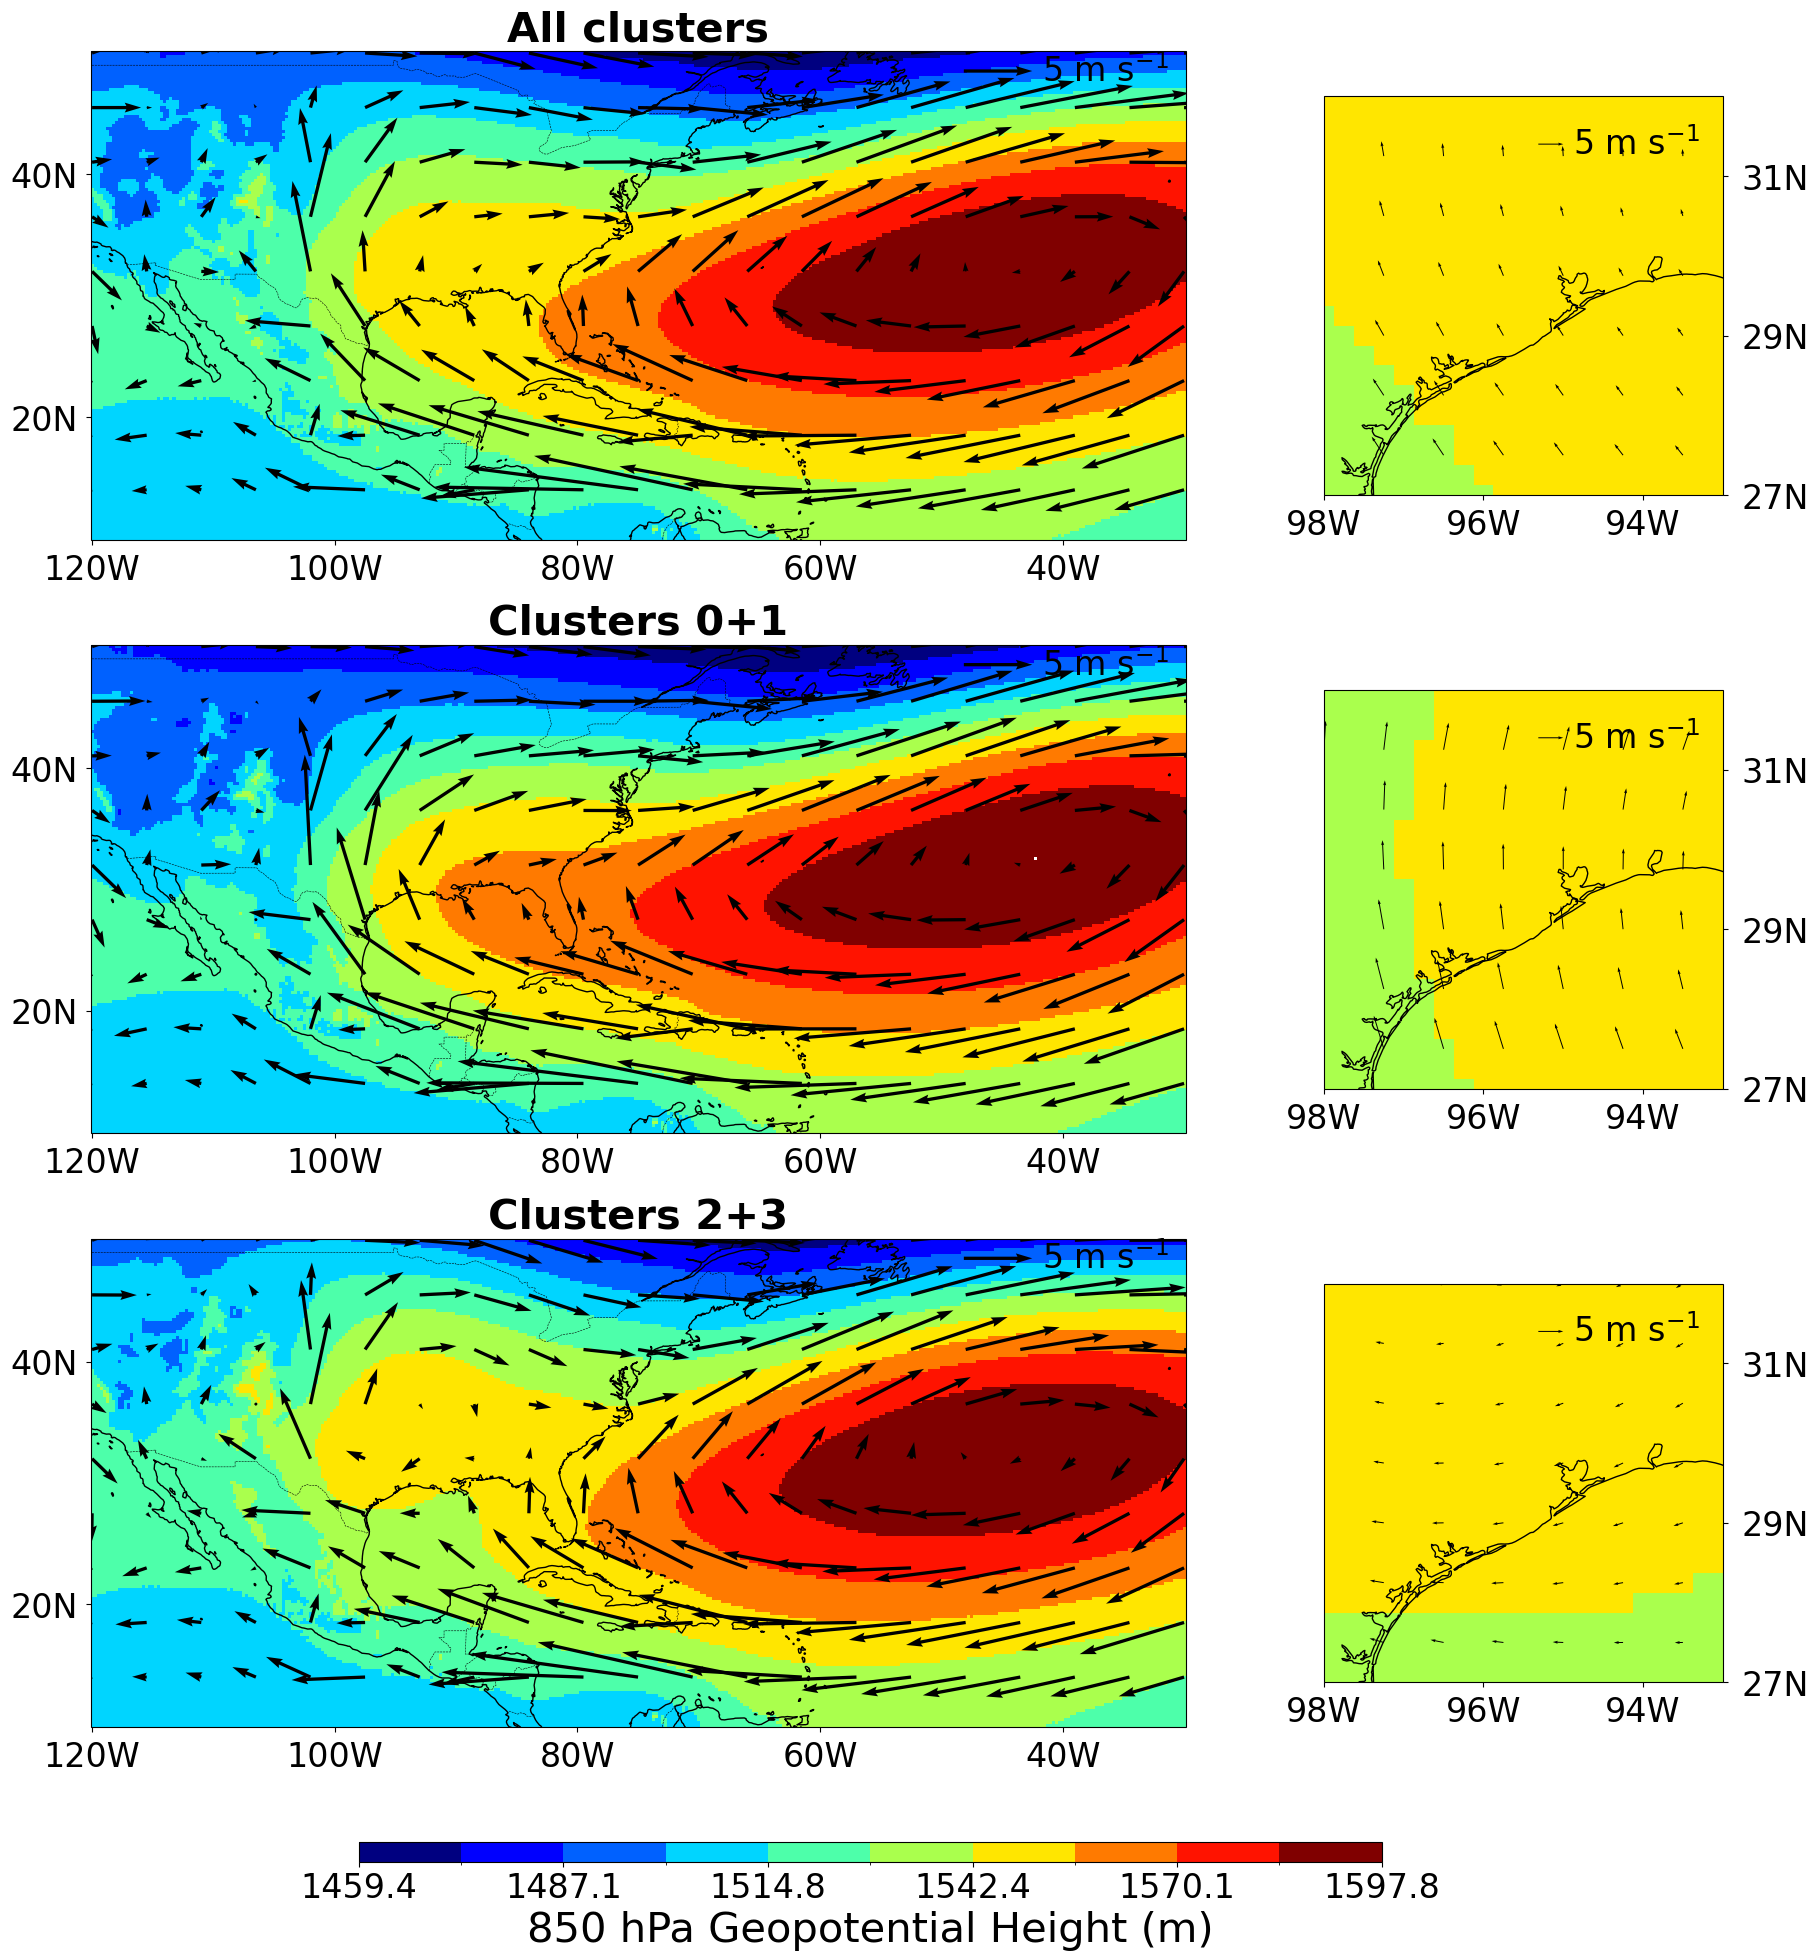

In [1]:
# -*- coding: utf-8 -*-
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# Match earlier plot formatting
# -----------------------------
plt.rcParams.update({
    "font.size": 26,
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24,
    "figure.titlesize": 28,
})

TICK_FS     = plt.rcParams["xtick.labelsize"]
TITLE_FS    = plt.rcParams["axes.titlesize"]
CBAR_LBL    = plt.rcParams["axes.labelsize"]
CBAR_TCK    = plt.rcParams["xtick.labelsize"]
QUIVKEY_FS  = plt.rcParams["legend.fontsize"]

# -----------------------------
# Load per-cluster files
# -----------------------------
dsM0 = xr.open_dataset("composite_mean_local_1998_2024_cluster_0.nc")
dsM1 = xr.open_dataset("composite_mean_local_1998_2024_cluster_1.nc")
dsM2 = xr.open_dataset("composite_mean_local_1998_2024_cluster_2.nc")
dsM3 = xr.open_dataset("composite_mean_local_1998_2024_cluster_3.nc")

dsU0 = xr.open_dataset("composite_mean_u_1998_2024_cluster_0.nc")
dsU1 = xr.open_dataset("composite_mean_u_1998_2024_cluster_1.nc")
dsU2 = xr.open_dataset("composite_mean_u_1998_2024_cluster_2.nc")
dsU3 = xr.open_dataset("composite_mean_u_1998_2024_cluster_3.nc")

dsV0 = xr.open_dataset("composite_mean_v_1998_2024_cluster_0.nc")
dsV1 = xr.open_dataset("composite_mean_v_1998_2024_cluster_1.nc")
dsV2 = xr.open_dataset("composite_mean_v_1998_2024_cluster_2.nc")
dsV3 = xr.open_dataset("composite_mean_v_1998_2024_cluster_3.nc")

# -----------------------------
# Select 850 hPa
# -----------------------------
gh0 = dsM0.z.sel(pressure_level=850.0)
gh1 = dsM1.z.sel(pressure_level=850.0)
gh2 = dsM2.z.sel(pressure_level=850.0)
gh3 = dsM3.z.sel(pressure_level=850.0)

u0 = dsU0.u.sel(pressure_level=850.0)
u1 = dsU1.u.sel(pressure_level=850.0)
u2 = dsU2.u.sel(pressure_level=850.0)
u3 = dsU3.u.sel(pressure_level=850.0)

v0 = dsV0.v.sel(pressure_level=850.0)
v1 = dsV1.v.sel(pressure_level=850.0)
v2 = dsV2.v.sel(pressure_level=850.0)
v3 = dsV3.v.sel(pressure_level=850.0)

# -----------------------------
# Build 3-row set:
#   Row 1: All clusters (0 3)
#   Row 2: Clusters 0+1
#   Row 3: Clusters 2+3
# -----------------------------
gh_ALL = (gh0 + gh1 + gh2 + gh3) / 4.0
u_ALL  = (u0  + u1  + u2  + u3)  / 4.0
v_ALL  = (v0  + v1  + v2  + v3)  / 4.0

gh_A = (gh0 + gh1) / 2.0
u_A  = (u0  + u1)  / 2.0
v_A  = (v0  + v1)  / 2.0

gh_B = (gh2 + gh3) / 2.0
u_B  = (u2  + u3)  / 2.0
v_B  = (v2  + v3)  / 2.0

GH = [gh_ALL, gh_A, gh_B]
UU = [u_ALL,  u_A,  u_B]
VV = [v_ALL,  v_A,  v_B]
row_titles = ["All clusters", "Clusters 0+1", "Clusters 2+3"]

# Lat/Lon from the all-cluster field
lats = u_ALL.latitude
lons = u_ALL.longitude

# -----------------------------
# Common colorbar range (across all 3 rows)
# -----------------------------
vmin_mean = float(xr.concat(GH, dim="combo").min())
vmax_mean = float(xr.concat(GH, dim="combo").max())
levels = np.linspace(vmin_mean, vmax_mean, 11)

# -----------------------------
# Zoom bounds
# -----------------------------
small_lat_min, small_lat_max = 27.0, 32.0
small_lon_min, small_lon_max = -98.0, -93.0

lat_ascending = bool(lats.diff("latitude").mean() > 0)
lon_ascending = bool(lons.diff("longitude").mean() > 0)

def slice_lat(a, b):
    return slice(a, b) if lat_ascending else slice(b, a)

def slice_lon(a, b):
    if float(lons.max()) > 180:
        a360 = (a + 360) if a < 0 else a
        b360 = (b + 360) if b < 0 else b
        return slice(a360, b360) if lon_ascending else slice(b360, a360)
    else:
        return slice(a, b) if lon_ascending else slice(b, a)

def label_format_lon(vals):
    return [f"{abs(v):.0f}W" if v < 0 else f"{v:.0f}E" for v in vals]

def label_format_lat(vals):
    return [f"{abs(v):.0f}S" if v < 0 else f"{v:.0f}N" for v in vals]

def format_map(ax, big=True):
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linestyle="--", linewidth=0.4)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray", alpha=0.4)

    if big:
        lon_ticks = np.arange(np.floor(float(lons.min())/20)*20,
                              np.ceil(float(lons.max())/20)*20 + 1, 20)
        lat_ticks = np.arange(np.floor(float(lats.min())/20)*20,
                              np.ceil(float(lats.max())/20)*20 + 1, 20)
    else:
        lon_ticks = np.arange(small_lon_min, small_lon_max + 0.01, 2)
        lat_ticks = np.arange(small_lat_min, small_lat_max + 0.01, 2)

    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels(label_format_lon(lon_ticks), fontsize=TICK_FS)
    ax.set_yticklabels(label_format_lat(lat_ticks), fontsize=TICK_FS)

    # keep small-panel y ticks on the right (cleaner spacing)
    if not big:
        ax.yaxis.set_ticks_position("right")
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis="y", pad=10)
    else:
        ax.tick_params(axis="y", pad=6)

    ax.tick_params(axis="x", pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# Figure & GridSpec (3 rows + colorbar row)
# -----------------------------
fig = plt.figure(figsize=(22, 20))
gs = fig.add_gridspec(
    4, 2,
    height_ratios=[1.0, 1.0, 1.0, 0.08],  # last row reserved for colorbar
    width_ratios=[1.4, 0.45],
    wspace=0.08,
    hspace=0.28
)

# Quiver density
big_stride = 18
small_stride = 3

last_mappable = None

for i, (gh, u, v, ttl) in enumerate(zip(GH, UU, VV, row_titles)):
    # Big plot (left)
    ax_big = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    format_map(ax_big, big=True)

    m = gh.plot(
        ax=ax_big, cmap="jet",
        vmin=vmin_mean, vmax=vmax_mean,
        levels=levels,
        add_colorbar=False, add_labels=False
    )
    last_mappable = m

    q_big = ax_big.quiver(
        lons.values[::big_stride], lats.values[::big_stride],
        u.values[::big_stride, ::big_stride], v.values[::big_stride, ::big_stride],
        scale=80, width=0.003, color="black"
    )

    # Titles: first row must say "All clusters"
    ax_big.set_title(ttl, fontsize=TITLE_FS, fontweight="bold", pad=8)

    ax_big.quiverkey(
        q_big, 0.86, 0.96, 5, r"5 m s$^{-1}$",
        labelpos="E", coordinates="axes",
        fontproperties={"size": QUIVKEY_FS}
    )

    # Zoom plot (right)
    ax_small = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    format_map(ax_small, big=False)

    gh_s = gh.sel(latitude=slice_lat(small_lat_min, small_lat_max),
                  longitude=slice_lon(small_lon_min, small_lon_max))
    u_s  = u.sel(latitude=slice_lat(small_lat_min, small_lat_max),
                 longitude=slice_lon(small_lon_min, small_lon_max))
    v_s  = v.sel(latitude=slice_lat(small_lat_min, small_lat_max),
                 longitude=slice_lon(small_lon_min, small_lon_max))

    gh_s.plot(
        ax=ax_small, cmap="jet",
        vmin=vmin_mean, vmax=vmax_mean,
        levels=levels,
        add_colorbar=False, add_labels=False
    )

    q_small = ax_small.quiver(
        gh_s.longitude.values[::small_stride], gh_s.latitude.values[::small_stride],
        u_s.values[::small_stride, ::small_stride], v_s.values[::small_stride, ::small_stride],
        scale=80, width=0.0025, color="black"
    )

    ax_small.set_extent([small_lon_min, small_lon_max, small_lat_min, small_lat_max],
                        crs=ccrs.PlateCarree())

    ax_small.quiverkey(
        q_small, 0.60, 0.88, 5, r"5 m s$^{-1}$",
        labelpos="E", coordinates="axes",
        fontproperties={"size": QUIVKEY_FS}
    )

# -----------------------------
# Common colorbar (bottom row spans both columns)
# -----------------------------
cbar_ax = fig.add_subplot(gs[3, :])
cbar_ax.axis("off")

bar = cbar_ax.inset_axes([0.20, 0.25, 0.60, 0.50])  # [left, bottom, width, height]
cbar = fig.colorbar(last_mappable, cax=bar, orientation="horizontal")
cbar.set_label("850 hPa Geopotential Height (m)", fontsize=CBAR_LBL)
cbar.ax.tick_params(labelsize=CBAR_TCK)

fig.subplots_adjust(bottom=0.06, top=0.97)

plt.savefig("850hPa_GH_Wind_3rows_All_then_01_then_23.png", dpi=600,
            bbox_inches="tight", pad_inches=0.2)
plt.show()